# Dictionaries, Sets, and Files

A **collection** is an object that contains other objects.  You can think of it like the English word collection, a car collection is a bunch of cars, a toy collection is a bunch of toys.  We have seen several build-in collection types in Python, including lists, tuples, and strings.  These are all sequence type collections, whose elements have a specific order that are accessed by an integer value index.  This lesson introduces two **unordered** collection types, dictionaries and sets:

*   **Dictionary**: Unordered and mutable collection whose elements are key-value pairs, where the keys are unique and hashable.  Dictionary syntax has comma-separated `key`:`value` pairs enclosed in curly brackets `{}`, like `{'a':1, 'b':2, 'c':3}` .

*   **Set**: Unorderd and mutable collection of unique, hashable elements.  Set syntax has elements enclosed in curly brackets `{}`, like `{1, 2, 3}`.


We have seen the meanings of ordered and mutable in the previous lesson, but hashable is a new concept in this lesson.  

A **hashable** object has a permanent, unchanging 'fingerprint' (called a hash value).  For example, a person's name is not a hash value because you can change it.  A person's Social Insurance Number is more like a hash value because it does not change over you lifetime.  Tuples and strings are hashable objects because they are immutable, while a list is not a hashable object because it is mutable.  

In addition to covering dictionaries and sets in detail, this lesson with cover input and output (I/O) files.  Files are not inherently related to dictionaries and sets, they are included in this lesson because they are not large enough a topic to warrant their own lesson.


### Before you begin...

Once again, before working through the lesson, run the following code.

In [13]:
from os.path import basename, exists

def download(url):
    filename = basename(url)
    if not exists(filename):
        from urllib.request import urlretrieve

        local, _ = urlretrieve(url, filename)
        print("Downloaded " + str(local))
    return filename

download('https://github.com/Hamilton-at-CapU/comp115/raw/main/modules/thinkpython.py')
download('https://github.com/Hamilton-at-CapU/comp115/raw/main/modules/diagram.py')

import thinkpython

## Dictionaries

A **dictionary** is like a list, but more general.
In a list, the indices have to be integers; in a dictionary they can be (almost) any type.
For example, suppose we make a list of number words, like this.

In [2]:
alist = ['zero', 'one', 'two']

We can use an integer as an index to get the corresponding word.

In [3]:
alist[1]

'one'

But suppose we want to go in the other direction, and look up a word to get the corresponding integer.
We can't do that with a list, but we can with a dictionary.
We'll start by creating an empty dictionary and assigning it to `numbers`.

In [4]:
numbers = {}
numbers

{}

The curly braces, `{}`, represent an empty dictionary.
To add items to the dictionary, we'll use square brackets.

In [5]:
numbers['zero'] = 0

This assignment adds to the dictionary an **item**, which represents the association of a **key** and a **value**.
In this example, the key is the string `'zero'` and the value is the integer `0`.
If we display the dictionary, we see that it contains one item, which contains a key and a value separated by a colon, `:`.

In [6]:
numbers

{'zero': 0}

We can add more items like this.

In [7]:
numbers['one'] = 1
numbers['two'] = 2
numbers

{'zero': 0, 'one': 1, 'two': 2}

Now the dictionary contains three items.

To look up a key and get the corresponding value, we use the square bracket operator.

In [8]:
numbers['two']

2

If the key isn't in the dictionary, we get a `KeyError`.

In [9]:
%%expect KeyError
numbers['three']


KeyError: 'three'

We can avoid the risk of a KeyError by using the `get()` method

In [10]:
numbers.get('three')

which (by default) returns `None` if the key does not exist.  The `get()` method can also be used with an additional argument that specifies the default return value if the key does not exist

In [12]:
numbers.get('three', 'key not found')

'key not found'

The `len` function works on dictionaries; it returns the number of items.

In [13]:
len(numbers)

3

In mathematical language, a dictionary represents a **mapping** from keys to values, so you can also say that each key "maps to" a value.
In this example, each number word maps to the corresponding integer.

The following figure shows the state diagram for `numbers`.

In [14]:
from diagram import make_dict, Binding, Value

d1 = make_dict(numbers, dy=-0.3, offsetx=0.37)
binding1 = Binding(Value('numbers'), d1)

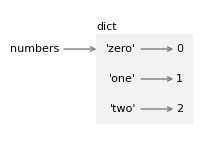

In [15]:
from diagram import diagram, adjust, Bbox

width, height, x, y = [1.83, 1.24, 0.49, 0.85]
ax = diagram(width, height)
bbox = binding1.draw(ax, x, y)
# adjust(x, y, bbox)

A dictionary is represented by a box with the word "dict" outside and the items inside.
Each item is represented by a key and an arrow pointing to a value.
The quotation marks indicate that the keys here are strings, not variable names.

### creating a dictionary

In the previous section we created an empty dictionary and added items one at a time using the bracket operator.
Instead, we could have created the dictionary all at once like this.

In [16]:
numbers = {'zero': 0, 'one': 1, 'two': 2}

Each item consists of a key and a value separated by a colon.
The items are separated by commas and enclosed in curly braces.

Another way to create a dictionary is to use the `dict` function.
We can make an empty dictionary like this.

In [17]:
empty = dict()
empty

{}

And we can make a copy of a dictionary like this.

In [18]:
numbers_copy = dict(numbers)
numbers_copy

{'zero': 0, 'one': 1, 'two': 2}

It is often useful to make a copy before performing operations that modify dictionaries because dictionaries are mutable.  We can change the value associated to a key like this.

In [19]:
numbers['two'] = 10
numbers

{'zero': 0, 'one': 1, 'two': 10}

### accessing all keys and values

To access a 'list' of all the keys and values of a dictionary, you can use the `keys()`, and `values()` methods.

In [21]:
numbers.keys()

dict_keys(['zero', 'one', 'two'])

In [24]:
numbers.values()

dict_values([0, 1, 10])

You may have noticed that the returned objects look like lists, but are in fact `dict_keys`, and `dict_values`.  These `dict_` objects are techincally not lists, but they act like lists for everything we will do in this course.  If you really want, you can cast them into lists using the `list()` function

In [27]:
list(numbers.keys())

['zero', 'one', 'two']

If you want to access the keys and values together, you can use the `items()` method that returns a 'list' of tuples corresponding to the `(key, value)` pairs in the dictionary

In [29]:
numbers.items()

dict_items([('zero', 0), ('one', 1), ('two', 10)])

### the in operator

The `in` operator works on dictionaries, too; it tells you whether something appears as a **key** in the dictionary.

In [30]:
'one' in numbers

True

The `in` operator does *not* check whether something appears as a value.

In [31]:
1 in numbers

False

To see whether something appears as a value in a dictionary, you can use the `values()` method

In [ ]:
1 in numbers.values()

True

## Example: a letter counter



Suppose you are given a string and you want to count how many times each letter appears.
A dictionary is a good tool for this job.
We'll start with an empty dictionary.

In [ ]:
counter = {}

As we loop through the letters in the string, suppose we see the letter `'a'` for the first time.
We can add it to the dictionary like this.

In [ ]:
counter['a'] = 1

The value `1` indicates that we have seen the letter once.
Later, if we see the same letter again, we can increment the counter like this.

In [ ]:
counter['a'] += 1

Now the value associated with `'a'` is `2`, because we've seen the letter twice.

In [ ]:
counter

{'a': 2}

The following function uses these features to count the number of times each letter appears in a string.

In [41]:
def value_counts(astring):
    counter = {}
    for letter in astring:
        if letter not in counter:
            counter[letter] = 1
        else:
            counter[letter] += 1
    return counter

Each time through the loop, if `letter` is not in the dictionary, we create a new item with key `letter` and value `1`.
If `letter` is already in the dictionary we increment the value associated with `letter`.

Here's an example.

In [42]:
counter = value_counts('brontosaurus')
counter

{'b': 1, 'r': 2, 'o': 2, 'n': 1, 't': 1, 's': 2, 'a': 1, 'u': 2}

The items in `counter` show that the letter `'b'` appears once, `'r'` appears twice, and so on.

## Looping and dictionaries



If you use a dictionary in a `for` statement, it traverses the keys of the dictionary.
To demonstrate, let's make a dictionary that counts the letters in `'banana'`.

In [43]:
counter = value_counts('banana')
counter

{'b': 1, 'a': 3, 'n': 2}

The following loop prints the keys, which are the letters.

In [44]:
for key in counter:
    print(key)

b
a
n


To print the values, we can use the `values` method.

In [45]:
for value in counter.values():
    print(value)

1
3
2


To print the keys and values, we can loop through the keys and look up the corresponding values.

In [46]:
for key in counter:
    value = counter[key]
    print(key, value)

b 1
a 3
n 2


Alternatively, you can use the `items()` method

In [47]:
for key, value in counter.items():
    print(key, value)

b 1
a 3
n 2


Notice that this loop updates *both* the key and the value variables each iteration as it loops over the (key, value) pairs returned by the `items()` method.

## Lists and Tuples with Dictionaries


You can put a list in a dictionary as a value.
For example, here's a dictionary that maps from the number `4` to a list of four letters.

In [1]:
a_dict = {4: ['r', 'o', 'u', 's']}
a_dict

{4: ['r', 'o', 'u', 's']}

But you can't put a list in a dictionary as a key.
Here's what happens if we try.

In [2]:
%%expect TypeError
letters = list('abcd')
a_dict[letters] = 4

UsageError: Cell magic `%%expect` not found.


I mentioned earlier that dictionaries use hash tables, and that means that the keys have to be **hashable**.

A **hash** is a function that takes a value (of any kind) and returns an integer.
Dictionaries use these integers, called hash values, to store and look up keys.
This system only works if a key is immutable, so its hash value is always the same.
But if a key is mutable, its hash value could change, and the dictionary would not work.
That's why keys have to be hashable, and why mutable types like lists aren't hashable.

Since dictionaries are mutable, they are not hashable, therefore they can't be used as dictionary keys.  But they *can* be used as values.

Tuples, on the other hand, can be used as keys because they are immutable and thus hashable.

In [4]:
b_dict = {}
letters = tuple('abcd')
b_dict[letters] = 42
b_dict

{('a', 'b', 'c', 'd'): 42}

## Using Zip to make a dictionary

`zip` is a handy built-in function that takes two or more sequences and returns a **zip object**, so-called because it pairs up the elements of the sequences like the teeth of a zipper.  We will use it here to quickly build a dictionary from two lists.

Image you have two lists, one being a list of food items, the other being a list of the prices of those items.

In [ ]:
foods = ["burger", "fries", "coke", "pizza", "elderberry"]
prices = [8.90, 2.50, 1.25, 5.50, 1.20]

Let's `zip` them together, to make a 'menu'.  I will also cast the zipped object into a list to make using it easier in the future.

In [ ]:
menu = list(zip(foods, prices))
menu

[('burger', 8.9),
 ('fries', 2.5),
 ('coke', 1.25),
 ('pizza', 5.5),
 ('elderberry', 1.2)]

We can loop through the menu

In [ ]:
for food, price in menu:
    print(food, price)

burger 8.9
fries 2.5
coke 1.25
pizza 5.5
elderberry 1.2


Or use it to make a dictionary

In [ ]:
price = dict(menu)
price['fries']

2.5

## Inverting a dictionary

Suppose you want to invert a dictionary so you can look up a value and get the corresponding key.
For example, if you have a word counter that maps from each word to the number of times it appears, you could make a dictionary that maps from integers to the words that appear that number of times.

But there's a problem -- the keys in a dictionary have to be unique, but the values don't. For example, in a word counter, there could be many words with the same count.

So one way to invert a dictionary is to create a new dictionary where the values are lists of keys from the original.
As an example, let's count the letters in `parrot`.

In [ ]:
d =  value_counts('parrot')
d

If we invert this dictionary, the result should be `{1: ['p', 'a', 'o', 't'], 2: ['r']}`, which indicates that the letters that appear once are `'p'`, `'a'`, `'o'`, and `'t'`, and the letter than appears twice is `'r'`.

The following function takes a dictionary and returns its inverse as a new dictionary.

In [ ]:
def invert_dict(d):
    new = {}
    for key, value in d.items():
        if value not in new:
            new[value] = [key]
        else:
            new[value].append(key)
    return new

The `for` statement loops through the keys and values in `d`.
If the value is not already in the new dictionary, it is added and associated with a list that contains a single element.
Otherwise it is appended to the existing list.

We can test it like this:

In [ ]:
invert_dict(d)

And we get the result we expected.

This is the first example we've seen where the values in the dictionary are lists.
We will see more!

## Sets



A **set** is a collection of unique elements.  The primary difference between a list and a set, is that a set can not have duplicate objects and each object in a set must be hashable (ie. immutable).  You can initialize a set by enclosing a list or tuple of objects in curly braces 

In [ ]:
a_set = {1, 2, 3, 4, 4, 4}
a_set

{1, 2, 3, 4}

Notice that while the original list had three 4's, the set only has one because duplicates are removed when the set is created.  You can also initialize a set with the `set()` function

In [10]:
another_set = set('banana')
another_set

{'a', 'b', 'n'}

This set initialized by a string only contains `a`, `b`, and `n` because those are all the unique characters in `banana`.  If you want to have strings as elements of a set, they need to be included in a list or tuple

In [13]:
yet_another_set = set(['abracadabra', 'magic', 'banana'])
yet_another_set

{'abracadabra', 'banana', 'magic'}

Did you notice that the order of the abracadabra magic banana changed to abracadabra banana magic?  This is because sets are unordered and means that we can not access elements using an index

In [15]:
%%expect TypeError
yet_another_set[1]

TypeError: 'set' object is not subscriptable

An object that is 'not subscriptable' means that it does not have elements that can be accessed with an index.  The word 'subcriptable' comes from the mathematical meaning of subscript; as in, '$x_i$ is the $i^{th}$ value of $x$'

The elements of a set must be hashable/immutable, so lists can not be elements of a set.

In [ ]:
%%expect TypeError
set_of_lists = set([[1, 2], [3, 4]])
set_of_lists

TypeError: unhashable type: 'list'

but tuples can be elements of a set because they are immutable

In [56]:
set_of_tuples = set([(1, 2), (3, 4)])
set_of_tuples

{(1, 2), (3, 4)}

you can add a single element to a set using the `add()` method

In [57]:
set_of_tuples.add((5, 6))
set_of_tuples

{(1, 2), (3, 4), (5, 6)}

you can add a list of elements to a set using the `update()` method

In [58]:
set_of_tuples.update([(7, 8), (9, 10)])
set_of_tuples

{(1, 2), (3, 4), (5, 6), (7, 8), (9, 10)}

### set operators and methods

In [52]:
pet_animals = {"dog", "cat", "hamster", "parrot"}
farm_animals = {"cow", "chicken", "goat", "dog", "cat"}

The **union** of two sets is a new set that contains all the elements from both sets.  The union operator is the `|` symbol, the union method is `union()`.

In [7]:
pet_animals | farm_animals

{'cat', 'chicken', 'cow', 'dog', 'goat', 'hamster', 'parrot'}

In [8]:
pet_animals.union(farm_animals)

{'cat', 'chicken', 'cow', 'dog', 'goat', 'hamster', 'parrot'}

The **intersection** of two sets is a new set that contains only the elements common to both sets.  The intersection operator symbol is `&`, the intersection method is `intersection()`

In [9]:
pet_animals & farm_animals

{'cat', 'dog'}

In [10]:
pet_animals.intersection(farm_animals)

{'cat', 'dog'}

The **difference** between two sets is the new set that contains elements that are in the first, but not in the second.  The difference operator symbol is `-`, and the difference method is `difference()`

In [11]:
pet_animals - farm_animals

{'hamster', 'parrot'}

In [27]:
pet_animals.difference(farm_animals)

{'hamster', 'parrot'}

## Files

For most computing tasks, we are going to want to provide the program with some inputs and produce some outputs in a format that can be saved for later.  There are many ways to format input/output (I/O) files, for this course we will simply use text files - that is files filled with characters.  Text files generally have the **.txt** file extension.  You can create a text file with a text editor program, like NotePad in Windows and TextEdit in Mac.  Note that document editors, like Word and Pages, produce files with text *plus* a bunch of formatting (like font types, sizes, colours, margins, etc) so **.docx** and **.pages** documents will not be readable with the simple file I/O tools we will be using.

### locating a file

The first step in reading a file is finding it.  Since these lessons are in Colab, we will focus on file locations in Colab.  The default location for Colab to look for a file is in the 'Files' tab, which you can open using the file folder icon on the left side of your Colab window 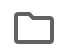. You can drag and drop files into this window to access them in your program.

You can also read files directly from your Google Drive in Colab by "**mounting**" your Google Drive.  If you want to got this route, ask Gemini to help you.  While you are welcome to use this method for your worksheets, please do not submit notebooks that require access to your Google Drive to run because I will not be able to run it unless I have access to your Google Drive - and I don't want access to your Google Drive.

### writing a file

To write a file using Python, we first open it with the **open()** function, then we write to it with the **write()** method, then we close it with the **close()** method.  

In the code below, we open a file called `silly_questions.txt` using the open() function that takes the file name and `'w'` as parameters, write some text to the file, then close the file.  Note that the open() function returns an object that I call `outfile`, then write and close are methods that are invoked on `outfile`.  

It is common for beginner programmers to confuse the file name with the file object.  In this case, `outfile` is the file object, `silly_questions.txt` is the file name (a string).

In [ ]:
outfile = open('silly_questions.txt', 'w')
outfile.write('What is your name?\n')
outfile.write('What is your quest?\n')
outfile.write('What is your favourite colour?\n')
outfile.write('What is the airspeed velocity of an unladen swallow?\n')
outfile.close()

<class '_io.TextIOWrapper'>


You should now be able to see the file 'silly_questions.txt' in the file tab on the left side of you Colab window.  Open it and add the following line, 
'What is the capital of Assyria?' (or whatever other question you would like to add)

Next we will read the file.

### reading a file

To read a file, open it with the **`open()`** function with the file name and `'r'` as parameters, read it with the **`read()`** method, then close it with the **`close()`** method.

Use the `'r'` parameter when opening a file for 'reading'.

Use the `'w'` parameter when opening a file for 'writing'.

In [36]:
infile = open('silly_questions.txt', 'r')
contents = infile.read()
infile.close()

print(contents)

What is your name?
What is your quest?
What is your favourite colour?
What is the airspeed velocity of an unladen swallow?



The `read()` method reads the entire file in at once, returning the contents of the file as a single string object.  This is not efficient for large files, so there is a **`readline()`** method that reads just one line at a time.

In [38]:
infile = open('silly_questions.txt', 'r')
line1 = infile.readline()
line2 = infile.readline()
line3 = infile.readline()
line4 = infile.readline()
infile.close()

print(line3)

What is your favourite colour?



We can put `readline()` into a `for` loop.  Notice that the `for` loop in this case is treating the file object, `infile`, like a collection of lines.  It loops through each line in the file in the same way that you might loop through the elements of a list.

In [43]:
infile = open('silly_questions.txt', 'r')
for line in infile:
    print(line)
infile.close()

What is your name?

What is your quest?

What is your favourite colour?

What is the airspeed velocity of an unladen swallow?



Notice that we always need to close the file.  Since we very rarely want open a file and not close it, Python has the `with` statement that will automatically close the file when the code block (ie. indentation) ends.

In [45]:
with open('silly_questions.txt', 'r') as infile:
    for line in infile:
        print(line)

What is your name?

What is your quest?

What is your favourite colour?

What is the airspeed velocity of an unladen swallow?



## Example: Searching for Reversible Words

Find all the pairs of words in the English language where one is the reverse of another -- like `stressed` and `desserts`.  To do this, use the `words.txt` file and write a file containting all the word pairs.  We will do this using two different algorithms to demonstrate that the algorithm you use can impact the performance of your program.

Start by downloading the `words.txt` file.  Note that the `download()` function will add the `words.txt` file to your Colab session, equivalent to dragging and dropping the file into the Files tab in Colab.

In [14]:
download('https://github.com/Hamilton-at-CapU/comp115/raw/main/datafiles/words.txt')

'words.txt'


Then read the `words.txt` file into a list.

In [15]:
word_file = open('words.txt')
words = word_file.read()   
word_list = words.split()
len(word_list)

113781

Note that the code above could be accomplished in a more compact way.

In [16]:
word_list = open('words.txt').read().split()
len(word_list)

113781

Now that we have the word list read from the `words.txt` file, let's search for palindromes using three different algorithms.

### Option 1. A Slow Algorithm

In this algorithm we will:
 * loop over each word in word_list
    * if the reversed word is `in` the word_list, save it to a tuple

Notice that this algorithm applies the `in` operator to the word list for each word in the word list.

Start with the `reverse_word` function from last lesson.

In [ ]:
def reverse_word(word):
    """Return the reversed version of a word."""
    return ''.join(reversed(word))

The following function loops through the words in the list.
For each word, it reverses the letters and then checks whether the reversed word is in the word list.

In [ ]:
def too_slow():
    reversible_words = []
    for word in word_list:
        if reverse_word(word) in word_list:
            reversible_words.append( (word, reverse_word(word)) )
    return reversible_words

This function takes more than a minute to run.
The problem is that the `in` operator checks the words in the list one at a time, starting at the beginning.
If it doesn't find what it's looking for -- which happens most of the time -- it has to search all the way to the end.

To measure how long a function takes, we can use `%time` which is one of Jupyter's "built-in magic commands".
These commands are not part of the Python language, so they might not work in other development environments.

In [31]:
%time too_slow()

CPU times: user 1min 12s, sys: 648 ms, total: 1min 13s
Wall time: 1min 13s


[('aa', 'aa'),
 ('aba', 'aba'),
 ('abut', 'tuba'),
 ('ad', 'da'),
 ('ados', 'soda'),
 ('aga', 'aga'),
 ('agar', 'raga'),
 ('agas', 'saga'),
 ('agenes', 'senega'),
 ('ah', 'ha'),
 ('aha', 'aha'),
 ('aider', 'redia'),
 ('airts', 'stria'),
 ('ajar', 'raja'),
 ('ala', 'ala'),
 ('alif', 'fila'),
 ('alula', 'alula'),
 ('am', 'ma'),
 ('ama', 'ama'),
 ('amen', 'nema'),
 ('amis', 'sima'),
 ('an', 'na'),
 ('ana', 'ana'),
 ('anger', 'regna'),
 ('animal', 'lamina'),
 ('animes', 'semina'),
 ('anna', 'anna'),
 ('anon', 'nona'),
 ('ante', 'etna'),
 ('are', 'era'),
 ('ares', 'sera'),
 ('aril', 'lira'),
 ('arris', 'sirra'),
 ('arum', 'mura'),
 ('at', 'ta'),
 ('ate', 'eta'),
 ('ates', 'seta'),
 ('auks', 'skua'),
 ('ava', 'ava'),
 ('avid', 'diva'),
 ('avo', 'ova'),
 ('awa', 'awa'),
 ('ay', 'ya'),
 ('bad', 'dab'),
 ('bag', 'gab'),
 ('bal', 'lab'),
 ('bals', 'slab'),
 ('ban', 'nab'),
 ('bard', 'drab'),
 ('bas', 'sab'),
 ('bat', 'tab'),
 ('bats', 'stab'),
 ('bed', 'deb'),
 ('ben', 'neb'),
 ('bib', 'bib'),
 

And the `in` operator is inside the loop, so it runs once for each word.
Since there are more than 100,000 words in the list, and for each one we check more than 100,000 words, the total number of comparisons is the number of words squared -- roughly -- which is almost 13 billion. 

In [21]:
len(word_list)**2

12946115961

### Option 2. A Fast Algorithm with a Dictionary

We can make this function much faster with a dictionary.  The items in a Python dictionary are stored in a **hash table**, which is a way of organizing data that has a remarkable property: the `in` operator takes about the same amount of time no matter how many items are in the dictionary.  That makes it possible to write some remarkably efficient algorithms.

The following loop creates a dictionary that contains the words as keys.

In [22]:
word_dict = {}
for word in word_list:
    word_dict[word] = 1

The values in `word_dict` are all `1`, but they could be anything, because we won't ever look them up -- we will only use this dictionary to check whether a key exists.

Now here's a version of the previous function that replaces `word_list` with `word_dict`.

In [ ]:
def much_faster():
    reversible_words = []
    for word in word_dict:
        if reverse_word(word) in word_dict:
            reversible_words.append( (word, reverse_word(word)) )
    return reversible_words

This function takes less than one hundredth of a second, so it's about 10,000 times faster than the previous version.

In general, the time it takes to find an element in a list is proportional to the length of the list.
The time it takes to find a key in a dictionary is almost constant -- regardless of the number of items.

In [33]:
%time much_faster()

CPU times: user 43.8 ms, sys: 5.72 ms, total: 49.5 ms
Wall time: 49.5 ms


[('aa', 'aa'),
 ('aba', 'aba'),
 ('abut', 'tuba'),
 ('ad', 'da'),
 ('ados', 'soda'),
 ('aga', 'aga'),
 ('agar', 'raga'),
 ('agas', 'saga'),
 ('agenes', 'senega'),
 ('ah', 'ha'),
 ('aha', 'aha'),
 ('aider', 'redia'),
 ('airts', 'stria'),
 ('ajar', 'raja'),
 ('ala', 'ala'),
 ('alif', 'fila'),
 ('alula', 'alula'),
 ('am', 'ma'),
 ('ama', 'ama'),
 ('amen', 'nema'),
 ('amis', 'sima'),
 ('an', 'na'),
 ('ana', 'ana'),
 ('anger', 'regna'),
 ('animal', 'lamina'),
 ('animes', 'semina'),
 ('anna', 'anna'),
 ('anon', 'nona'),
 ('ante', 'etna'),
 ('are', 'era'),
 ('ares', 'sera'),
 ('aril', 'lira'),
 ('arris', 'sirra'),
 ('arum', 'mura'),
 ('at', 'ta'),
 ('ate', 'eta'),
 ('ates', 'seta'),
 ('auks', 'skua'),
 ('ava', 'ava'),
 ('avid', 'diva'),
 ('avo', 'ova'),
 ('awa', 'awa'),
 ('ay', 'ya'),
 ('bad', 'dab'),
 ('bag', 'gab'),
 ('bal', 'lab'),
 ('bals', 'slab'),
 ('ban', 'nab'),
 ('bard', 'drab'),
 ('bas', 'sab'),
 ('bat', 'tab'),
 ('bats', 'stab'),
 ('bed', 'deb'),
 ('ben', 'neb'),
 ('bib', 'bib'),
 

In [ ]:
reversible_words = much_faster()
len(reversible_words)

885

### A Note on Acculating Lists

For many programming tasks, it is useful to loop through one list or dictionary while building another.
Both the fast and slow examples above use this technique:

* initialize an empty list of `reversible_words`

* make a loop over the full word list, if `word` is a reversible, we append it to the end of `reversible_words`.

* when the loop ends, `reversible_words` is a list of reversible words.

In this loop, `reversible_words` is used as an **accumulator**, which is a variable that collects or accumulates data during a computation.  Looping through a list like this, selecting some elements and omitting others, is called **filtering**.

### Removing duplicates

You may have noticed that non-palindrome words are duplicated in the list, like `('ah', 'ha')` and `('ha', 'ah')`.  

In [ ]:
('ah', 'ha') in reversible_words

True

In [ ]:
('ha', 'ah') in reversible_words

True

To remove these duplicates we can use `sets`.  The following function removes the duplicates by:
 * initializing an empty set
 * loop over each pair of words 
   * sort the word pair (so that the pair will be in alphabetical order)
   * add the alphabetized word pair to the set

In [66]:
def remove_duplicates(pairs):
    """Remove duplicates from a list of pairs."""
    unique_pairs = set()
    for pair in pairs:
        unique_pairs.add( tuple(sorted(pair)) )
    return unique_pairs

In [ ]:
unique_reverse_words = remove_duplicates(reversible_words)
len(unique_reverse_words)

488

Note that we have removed almost half of the word pairs from the list.

Finally, we can write the reversible words to a file.

In [69]:
with open('reversible_words.txt', 'w') as outfile:
    for word1, word2 in unique_reverse_words:
        outfile.write(f"{word1} {word2}\n")

You should now be able to see the `reversible_words.txt` file.  Did you notice that it is not alphabetized?  Do you know why not?  It is because sets are not ordered collections, so the original alphabetization of our word list got lost when we converted it to sets.

## Debugging



As you work with bigger datasets it can become unwieldy to debug by printing and checking the output by hand. Here are some suggestions for debugging large datasets:

1.  Scale down the input: If possible, reduce the size of the dataset. For example if the
    program reads a text file, start with just the first 10 lines, or
    with the smallest example you can find. You can either edit the
    files themselves, or (better) modify the program so it reads only
    the first `n` lines. If there is an error, you can reduce `n` to the smallest value where the error occurs. As you find and correct errors, you can increase `n` gradually.

2. Check summaries and types: Instead of printing and checking the entire dataset, consider
    printing summaries of the data -- for example, the number of items in
    a dictionary or the total of a list of numbers. A common cause of runtime errors is a value that is not the right type. For debugging this kind of error, it is often enough to print the type of a value.

3. Write self-checks: Sometimes you can write code to check for errors automatically. For
    example, if you are computing the average of a list of numbers, you
    could check that the result is not greater than the largest element
    in the list or less than the smallest. This is called a "sanity
    check" because it detects results that are "insane". Another kind of check compares the results of two different computations to see if they are consistent. This is called a "consistency check".

4. Format the output: Formatting debugging output can make it easier to spot an error. A tool you might find useful is the `pprint` module, which provides a `pprint` function that displays built-in types in a more human-readable format (`pprint` stands for "pretty print"). Again, time you spend building scaffolding can reduce the time you spend debugging.

## Glossary



**dictionary:**
 An object that contains key-value pairs, also called items.

**item:**
 In a dictionary, another name for a key-value pair.

**key:**
 An object that appears in a dictionary as the first part of a key-value pair.

**value:**
 An object that appears in a dictionary as the second part of a key-value pair. This is more specific than our previous use of the word "value".

**mapping:**
  A relationship in which each element of one set corresponds to an element of another set.

**hash table:**
A collection of key-value pairs organized so that we can look up a key and find its value efficiently.

**hashable:**
 Immutable types like integers, floats and strings are hashable.
 Mutable types like lists and dictionaries are not.

**hash function:**
A function that takes an object and computes an integer that is used to locate a key in a hash table.

**accumulator:**
 A variable used in a loop to add up or accumulate a result.

**filtering:**
Looping through a sequence and selecting or omitting elements.

**set:**
 An unordered collection of unique elements.



## Exercises

In [ ]:
# This cell tells Jupyter to provide detailed debugging information
# when a runtime error occurs. Run it before working on the exercises.

%xmode Verbose

### Ask a virtual assistant

In this chapter, I said the keys in a dictionary have to be hashable and I gave a short explanation. If you would like more details, ask a virtual assistant, "Why do keys in Python dictionaries have to be hashable?"

In [a previous section](section_dictionary_in_operator), we stored a list of words as keys in a dictionary so that we could use an efficient version of the `in` operator.
We could have done the same thing using a `set`, which is another built-in data type.
Ask a virtual assistant, "How do I make a Python set from a list of strings and check whether a string is an element of the set?"

### Exercise

Dictionaries have a method called `get` that takes a key and a default value. 
If the key appears in the dictionary, `get` returns the corresponding value; otherwise it returns the default value.
For example, here's a dictionary that maps from the letters in a string to the number of times they appear.

In [ ]:
counter = value_counts('brontosaurus')

If we look up a letter that appears in the word, `get` returns the number of times it appears.

In [ ]:
counter.get('b', 0)

If we look up a letter that doesn't appear, we get the default value, `0`.

In [ ]:
counter.get('c', 0)

Use `get` to write a more concise version of `value_counts`.
You should be able to eliminate the `if` statement.

### Exercise

What is the longest word you can think of where each letter appears only once?
Let's see if we can find one longer than `unpredictably`.

Write a function named `has_duplicates` that takes a sequence -- like a list or string -- as a parameter and returns `True` if there is any element that appears in the sequence more than once.

In [70]:
# Solution

def has_duplicates(t):
    """Check whether any element in a sequence appears more than once.
    t: sequence
    """
    d = {}
    for x in t:
        d[x] = True
    return len(d) < len(t)

In [71]:
assert has_duplicates('banana') == True
assert has_duplicates('ambidextrously') == False
assert has_duplicates([1, 2, 2]) == True
assert has_duplicates([1, 2, 3]) == False

You can use this loop to find the longest words with no repeated letters.

In [ ]:
no_repeats = []

for word in word_list:
    if len(word) > 12 and not has_duplicates(word):
        no_repeats.append(word)
        
no_repeats

### Exercise

Write a function called `find_repeats` that takes a dictionary that maps from each key to a counter, like the result from `value_counts`.
It should loop through the dictionary and return a list of keys that have counts greater than `1`.
You can use the following outline to get started.

In [ ]:
def find_repeats(counter):
    """Makes a list of keys with values greater than 1.
    
    counter: dictionary that maps from keys to counts
    
    returns: list of keys
    """
    return []

In [ ]:
# Solution

def find_repeats(counter):
    """Makes a list of keys with values greater than 1.
    
    counter: dictionary that maps from keys to counts
    
    returns: list of keys
    """
    repeats = []
    for key, count in counter.items():
        if count > 1:
            repeats.append(key)
    return repeats

You can use the following examples to test your code.
First, we'll make a dictionary that maps from letters to counts.

In [ ]:
counter1 = value_counts('banana')
counter1

The result from `find_repeats` should be `['a', 'n']`.

In [ ]:
repeats = find_repeats(counter1)
repeats

Here's another example that starts with a list of numbers.
The result should be `[1, 2]`.

In [ ]:
counter1 = value_counts([1, 2, 3, 2, 1])
repeats = find_repeats(counter1)
repeats

### Exercise

Suppose you run `value_counts` with two different words and save the results in two dictionaries.

In [ ]:
counter1 = value_counts('brontosaurus')
counter2 = value_counts('apatosaurus')

Each dictionary maps from a set of letters to the number of times they appear.
Write a function called `add_counters` that takes two dictionaries like this and returns a new dictionary that contains all of the letters and the total number of times they appear in either word.

There are many ways to solve this problem.
Once you have a working solution, consider asking a virtual assistant for different solutions.

In [ ]:
# Solution

def add_counters(counter1, counter2):
    result = dict(counter1)
    for letter, count in counter2.items():
        result[letter] = result.get(letter, 0) + count
    return result

In [ ]:
# Solution

add_counters(counter1, counter2)

### Exercise

A word is "interlocking" if we can split it into two words by taking alternating letters.
For example, "schooled" is an interlocking word because it can be split into "shoe" and "cold".

To select alternating letters from a string, you can use a slice operator with three components that indicate where to start, where to stop, and the "step size" between the letters.

In the following slice, the first component is `0`, so we start with the first letter.
The second component is `None`, which means we should go all the way to the end of the string.
And the third component is `2`, so there are two steps between the letters we select.

In [ ]:
word = 'schooled'
first = word[0:None:2]
first

Instead of providing `None` as the second component, we can get the same effect by leaving it out altogether.
For example, the following slice selects alternating letters, starting with the second letter.

In [ ]:
second = word[1::2]
second

Write a function called `is_interlocking` that takes a word as an argument and returns `True` if it can be split into two interlocking words.

In [ ]:
# Solution

def is_interlocking(word):
    first = word[0::2]
    second = word[1::2]
    return first in word_dict and second in word_dict

You can use the following loop to find the interlocking words in the word list.

In [ ]:
for word in word_list:
    if len(word) >= 8 and is_interlocking(word):
        first = word[0::2]
        second = word[1::2]
        print(word, first, second)

[Think Python: 3rd Edition](https://allendowney.github.io/ThinkPython/index.html)

Copyright 2024 [Allen B. Downey](https://allendowney.com), modified by Andrew Hamilton (2026)

Code license: [MIT License](https://mit-license.org/)

Text license: [Creative Commons Attribution-NonCommercial-ShareAlike 4.0 International](https://creativecommons.org/licenses/by-nc-sa/4.0/)